# Predição de Doença Cardíaca — Árvore de Decisão

Dataset: [Heart Disease Dataset (johnsmith88) — Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

Este notebook executa: carga dos dados, análise exploratória rápida, pré-processamento, treinamento de um modelo de Árvore de Decisão, avaliação com métricas de classificação e visualização da importância das variáveis.

## Objetivo do modelo

O objetivo do modelo é classificar se um paciente possui ou não doença cardíaca (variável `target`: 0 = sem doença, 1 = com doença), com base em 13 atributos clínicos como idade, pressão arterial, colesterol, frequência cardíaca máxima e tipo de dor no peito, entre outros.

## Como o modelo funciona

O modelo escolhido foi a **Árvore de Decisão (Decision Tree Classifier)**.

A Árvore de Decisão aprende, a partir dos dados de treino, uma sequência de perguntas do tipo "se/então" sobre as variáveis do paciente. Por exemplo: "o tipo de dor no peito (`cp`) é igual a 0? Se sim, siga para a esquerda; se não, siga para a direita". Cada pergunta divide o conjunto de pacientes em grupos cada vez mais "puros" (com predominância de uma única classe — doente ou não doente), até chegar a uma folha final, que é a decisão do modelo.

A escolha de qual variável e qual valor usar em cada divisão é feita automaticamente pelo algoritmo, buscando a divisão que mais separa as classes a cada passo (usando métricas como impureza de Gini ou entropia). Limitamos a profundidade da árvore (`max_depth=5`) para evitar que ela "memorize" demais os dados de treino (overfitting), o que a tornaria pouco precisa em pacientes novos.

## Por que esse modelo é adequado ao problema estudado

- É **altamente interpretável**: dá para visualizar literalmente o caminho de decisão (ex.: "tipo de dor no peito → número de vasos sanguíneos → idade"), o que é valioso em contexto médico, onde entender o "porquê" da decisão é tão importante quanto a decisão em si;
- Lida bem com a **mistura de variáveis numéricas e categóricas** presentes no dataset, sem exigir normalização;
- Captura **relações não-lineares** entre sintomas e diagnóstico sem necessidade de engenharia de variáveis complexa;
- É **rápido de treinar**, servindo como ótimo modelo-base antes de avaliar modelos mais robustos (como Random Forest ou Gradient Boosting), permitindo comparar se o ganho de complexidade vale a pena;
- Fornece **importância das variáveis**, mostrando quais sintomas mais influenciam o diagnóstico previsto.

## 1. Upload do dataset

Rode a célula abaixo e selecione o arquivo `heart.csv` quando solicitado.

In [3]:
from google.colab import files
uploaded = files.upload()  # selecione o arquivo heart.csv

Saving heart.csv to heart.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Análise exploratória (EDA) rápida

In [5]:
print("Dimensões:", df.shape)
print("\nValores nulos por coluna:")
print(df.isnull().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())
print("\nDistribuição da variável target:")
print(df['target'].value_counts())

df.describe()

Dimensões: (1025, 14)

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Linhas duplicadas: 723

Distribuição da variável target:
target
1    526
0    499
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


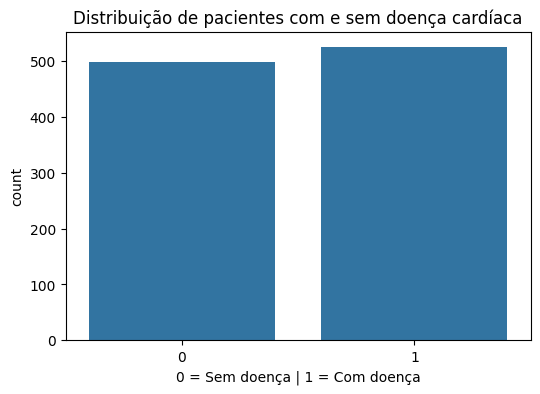

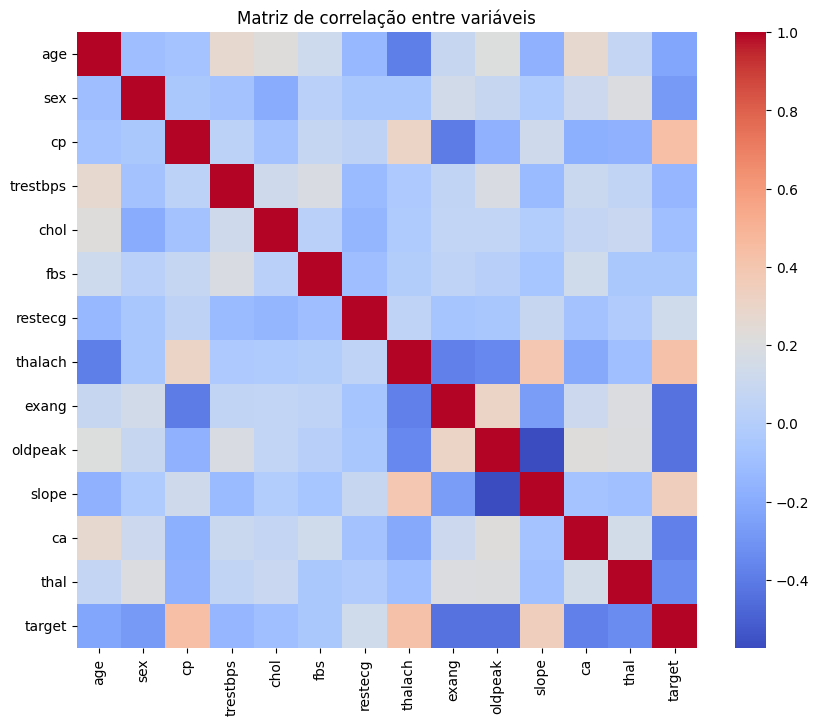

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title('Distribuição de pacientes com e sem doença cardíaca')
plt.xlabel('0 = Sem doença | 1 = Com doença')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de correlação entre variáveis')
plt.show()

## 3. Pré-processamento e divisão treino/teste

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (820, 13) | Teste: (205, 13)


## 4. Treinamento do modelo — Árvore de Decisão (Decision Tree Classifier)

A Árvore de Decisão aprende uma sequência de perguntas do tipo "se/então" sobre as variáveis (ex.: "o tipo de dor no peito é igual a X? Se sim, vá para a direita; senão, para a esquerda"), dividindo os pacientes em grupos cada vez mais puros (com predominância de uma única classe), até chegar a uma folha com a decisão final. Limitamos a profundidade (`max_depth`) para evitar que a árvore memorize demais os dados de treino (overfitting).

In [8]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## 5. Execução dos testes e métricas

In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Acurácia: ", round(accuracy_score(y_test, y_pred), 4))
print("Precisão: ", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1-score: ", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 4))
print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia:  0.8732
Precisão:  0.8624
Recall:    0.8952
F1-score:  0.8785
ROC-AUC:   0.9326

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       100
           1       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



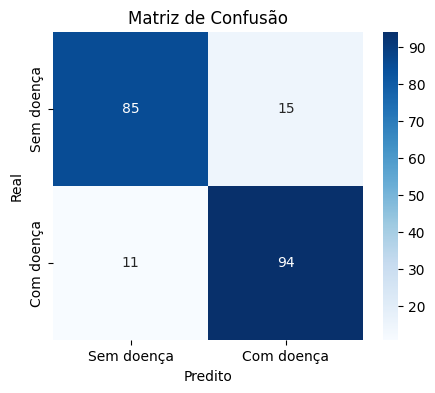

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem doença','Com doença'],
            yticklabels=['Sem doença','Com doença'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## 6. Visualização da árvore e importância das variáveis

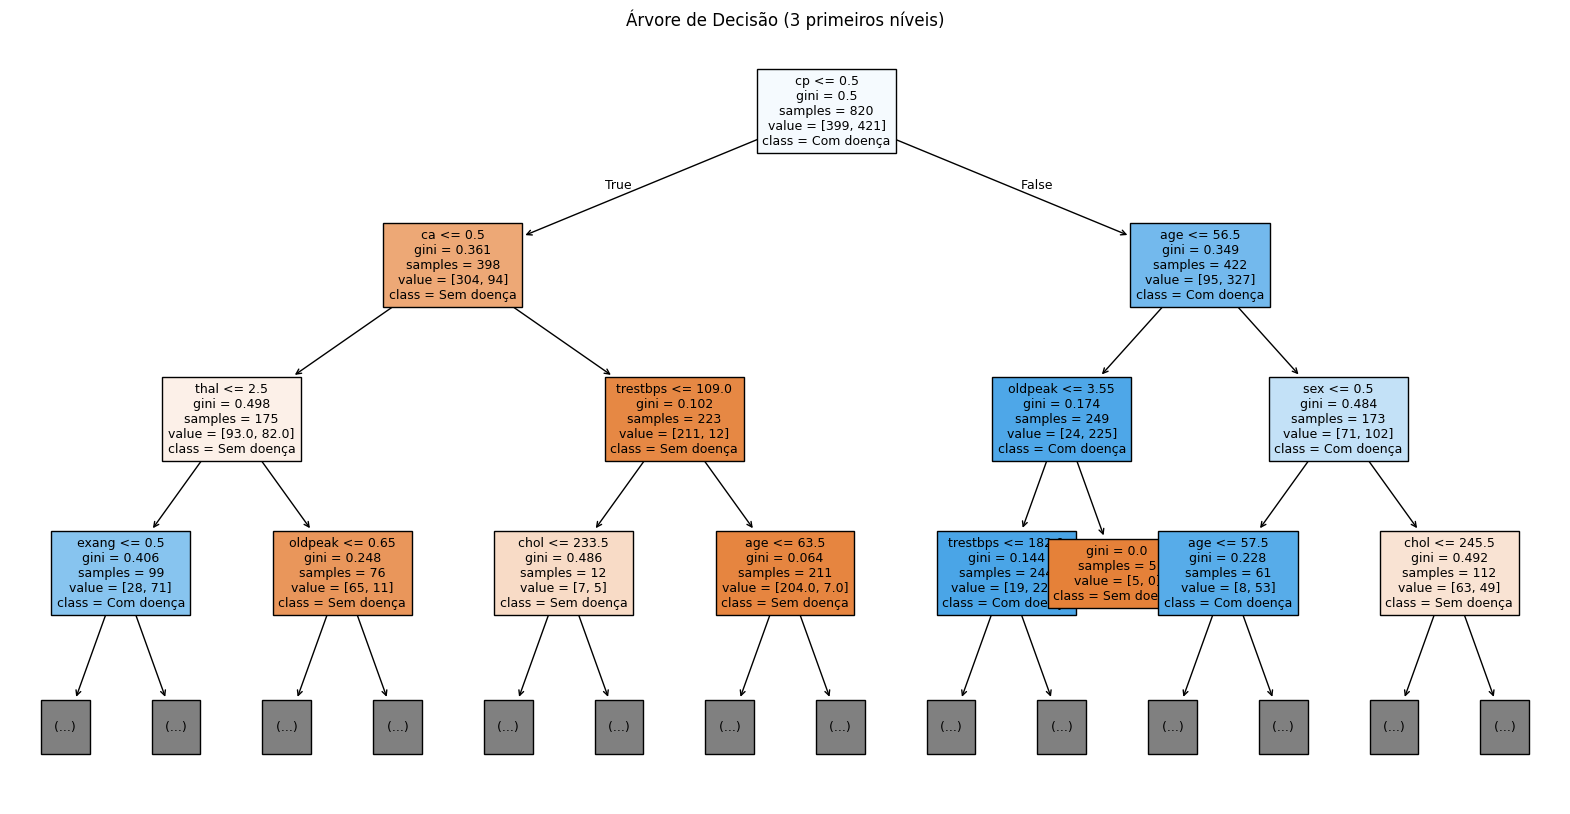

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['Sem doença','Com doença'],
          filled=True, max_depth=3, fontsize=9)
plt.title('Árvore de Decisão (3 primeiros níveis)')
plt.show()

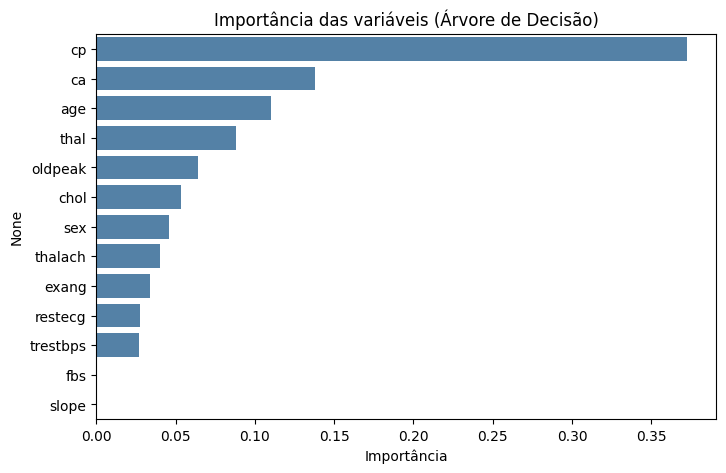

,0
cp,0.372280
ca,0.138164
age,0.109885
thal,0.088238
oldpeak,0.063845
chol,0.053462
sex,0.046021
thalach,0.040041
exang,0.034112
restecg,0.027317


In [12]:
importancias = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index, color='steelblue')
plt.title('Importância das variáveis (Árvore de Decisão)')
plt.xlabel('Importância')
plt.show()

importancias

## 7. Resultados da primeira execução (registro)

In [13]:
resultados = {
    'Acuracia': accuracy_score(y_test, y_pred),
    'Precisao': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_score': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba)
}
pd.DataFrame([resultados])

,Acuracia,Precisao,Recall,F1_score,ROC_AUC
0,0.873171,0.862385,0.895238,0.878505,0.932619
